In [16]:
import pickle, numpy as np, pandas as pd
with open("migration_no_drug_med_density.pkl", "rb") as f:
    output = pickle.load(f)
A_list = np.asarray(output["A_list"])          # (t, 40, 40), values 0/1
mpp = output["metadata"]["microns per lattice space"]   # 1 µm/px
dt  = output["metadata"]["time interval (mins)"]         # 5 min/frame

rows = []
for t, frame in enumerate(A_list):
    for (y, x) in np.argwhere(frame > 0.5):    # each occupied pixel = 1 spot
        rows.append({"frame": t, "y": float(y), "x": float(x)})
spots = pd.DataFrame(rows)

Size of data (t, 2D position):  (41, 40, 40)

Data Details: 
experiment - no drug
cell density - med
movie frames - 41
xy dimensions - 40
microns per lattice space - 1
time interval (mins) - 5


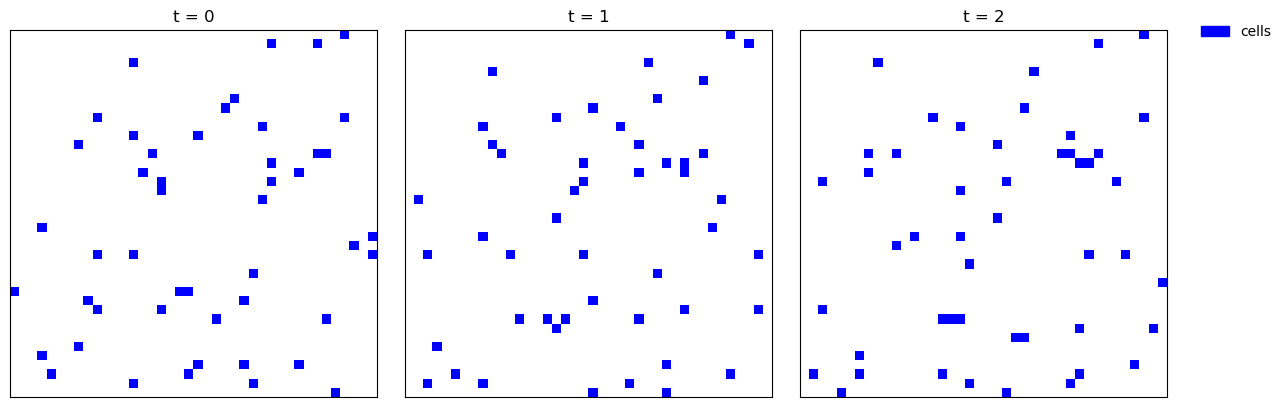

In [17]:
#loading and plotting data:
import matplotlib.pyplot as plt
import matplotlib as mpl
with open("migration_no_drug_med_density.pkl", "rb") as f:   # med density (was low)
    output = pickle.load(f)

A_list = np.asarray(output["A_list"])
metadata = output["metadata"]

print("Size of data (t, 2D position): ", np.shape(A_list)) 
print("\nData Details: ")
for key,value in metadata.items():
    print(key, "-",  value)

# discrete colormap:
cmaplist = [
    (1.0, 1.0, 1.0, 1.0),          # 0 empty
    (0.0, 0.0, 1.0, 1.0),          # 1 cell
]
cmap = mpl.colors.ListedColormap(cmaplist)

fig, axes = plt.subplots(1, 3, figsize=(12, 4))

for i, ax in enumerate(axes):
    ax.imshow(A_list[i], cmap=cmap) 
    ax.set_title(f"t = {i}")
    ax.set_xticks([]); ax.set_yticks([])

legend_patches = [
    mpl.patches.Patch(color=cmaplist[1], label='cells'),
]
fig.legend(handles=legend_patches, bbox_to_anchor=(1.0, 1), loc='upper left', frameon=False)
plt.tight_layout()
plt.show()

In [19]:
from laptrack import LapTrack

max_link = 10.0    # µm gate: max distance a cell can move per frame
lt = LapTrack(
    track_dist_metric="sqeuclidean",
    track_cost_cutoff=max_link**2,          # cutoffs are squared distances
    gap_closing_max_frame_count=2,          # bridge up to 2 missed frames
    gap_closing_cost_cutoff=(2*max_link)**2,
    splitting_cost_cutoff=False,            # no cell division in this data
    merging_cost_cutoff=False,              # no merging
)

track_df, _, _ = lt.predict_dataframe(
    spots, coordinate_cols=["x", "y"], frame_col="frame", only_coordinate_cols=False,
)
# track_df now has a 'track_id' column = one id per linked trajectory

In [20]:
def ensemble_msd(track_df, mpp, dt, max_lag=20):
    taus = np.arange(1, max_lag + 1)
    msd = []
    for lag in taus:
        sq = []
        for _, g in track_df.sort_values("frame").groupby("track_id"):
            xy = g[["x", "y"]].to_numpy() * mpp
            if len(xy) > lag:
                d = xy[lag:] - xy[:-lag]
                sq.extend((d**2).sum(1))
        msd.append(np.mean(sq))
    return taus * dt, np.array(msd)      # (tau in min, MSD in µm²)

In [21]:
track_df

,frame,y,x,tree_id,track_id
0,0,0.0,36.0,0,0
1,0,1.0,28.0,1,1
2,0,1.0,33.0,2,2
3,0,3.0,13.0,3,3
4,0,7.0,24.0,4,4
...,...,...,...,...,...
1963,40,37.0,20.0,41,41
1964,40,38.0,14.0,44,44
1965,40,38.0,32.0,33,33
1966,40,38.0,35.0,46,46


In [22]:
1968/41

48.0

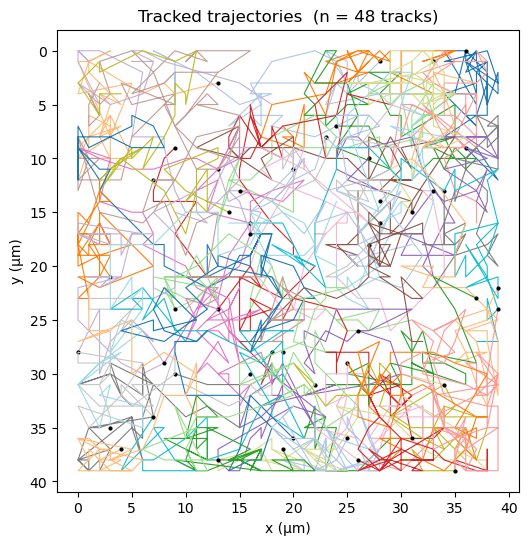

In [23]:
# ---  visualize the linked trajectories (matplotlib, works headless/inline) ---
import matplotlib.pyplot as plt
import matplotlib.cm as cm

fig, ax = plt.subplots(figsize=(6, 6))
for tid, g in track_df.groupby("track_id"):
    g = g.sort_values("frame")
    ax.plot(g["x"] * mpp, g["y"] * mpp, "-", lw=0.8, color=cm.tab20(int(tid) % 20))
    ax.plot(g["x"].iloc[0] * mpp, g["y"].iloc[0] * mpp, ".", ms=4, color="k")  # start
ax.set_aspect("equal"); ax.invert_yaxis()
ax.set_xlabel("x (µm)"); ax.set_ylabel("y (µm)")
ax.set_title(f"Tracked trajectories  (n = {track_df.track_id.nunique()} tracks)")
plt.show()

In [24]:
# --- 2) calculate the ensemble MSD(tau) using the function defined above ---
tau, msd = ensemble_msd(track_df, mpp, dt, max_lag=20)
for t, m in zip(tau, msd):
    print(f"tau = {t:3.0f} min   MSD = {m:6.2f} µm²")

tau =   5 min   MSD =   8.76 µm²
tau =  10 min   MSD =  15.98 µm²
tau =  15 min   MSD =  22.33 µm²
tau =  20 min   MSD =  28.96 µm²
tau =  25 min   MSD =  35.88 µm²
tau =  30 min   MSD =  42.97 µm²
tau =  35 min   MSD =  49.83 µm²
tau =  40 min   MSD =  56.13 µm²
tau =  45 min   MSD =  62.21 µm²
tau =  50 min   MSD =  68.32 µm²
tau =  55 min   MSD =  74.44 µm²
tau =  60 min   MSD =  79.78 µm²
tau =  65 min   MSD =  84.58 µm²
tau =  70 min   MSD =  89.53 µm²
tau =  75 min   MSD =  94.70 µm²
tau =  80 min   MSD =  99.12 µm²
tau =  85 min   MSD = 104.14 µm²
tau =  90 min   MSD = 108.80 µm²
tau =  95 min   MSD = 112.99 µm²
tau = 100 min   MSD = 117.50 µm²


MSD scaling exponent  alpha = 0.90


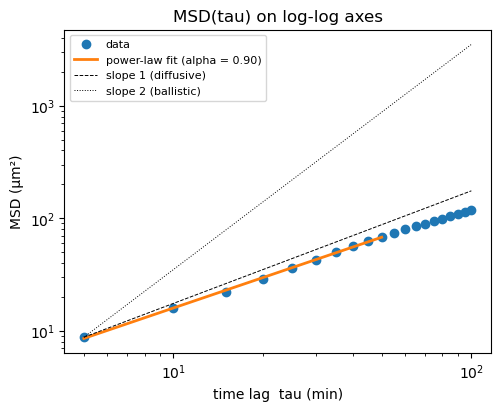

In [25]:
# --- 3) fit the log-log MSD vs tau to get the scaling exponent alpha ---
#     MSD ~ tau^alpha :  alpha=1 random walk (diffusive), alpha=2 straight line,
#     alpha<1 confined/crowded, 1<alpha<2 persistent/directed.
fit_n = 10                                    # short/mid lags = the reliable range
alpha, logA = np.polyfit(np.log(tau[:fit_n]), np.log(msd[:fit_n]), 1)
print(f"MSD scaling exponent  alpha = {alpha:.2f}")

fig, ax = plt.subplots(figsize=(5.5, 4.2))
ax.loglog(tau, msd, "o", label="data")
ax.loglog(tau[:fit_n], np.exp(logA) * tau[:fit_n] ** alpha, "-",
          lw=2, label=f"power-law fit (alpha = {alpha:.2f})")
ax.loglog(tau, msd[0] * (tau / tau[0]) ** 1, "k--", lw=.7, label="slope 1 (diffusive)")
ax.loglog(tau, msd[0] * (tau / tau[0]) ** 2, "k:",  lw=.7, label="slope 2 (ballistic)")
ax.set_xlabel("time lag  tau (min)"); ax.set_ylabel("MSD (µm²)")
ax.set_title("MSD(tau) on log-log axes"); ax.legend(fontsize=8)
plt.show()

In [23]:
# --- average velocity, assuming a random walk (alpha ~ 1):  v(tau) = sqrt(MSD(tau)) / tau ---
# (uses tau, msd from the MSD cell above)
v_tau = np.sqrt(msd) / tau                       # µm/min at each time lag
print("v(tau) = sqrt(MSD(tau)) / tau :")
for t, v in zip(tau[:6], v_tau[:6]):
    print(f"   tau = {t:3.0f} min   v = {v:.3f} µm/min")
print(f"\naverage speed at the shortest lag (tau = {dt} min):  v = {v_tau[0]:.3f} µm/min")
print("note: for a random walk MSD ~ tau, so v = sqrt(MSD)/tau ~ 1/sqrt(tau) --")
print(f"      v DECREASES with tau, so quote it at a fixed lag (here tau = {dt} min).")

v(tau) = sqrt(MSD(tau)) / tau :
   tau =   5 min   v = 0.562 µm/min
   tau =  10 min   v = 0.381 µm/min
   tau =  15 min   v = 0.303 µm/min
   tau =  20 min   v = 0.261 µm/min
   tau =  25 min   v = 0.233 µm/min
   tau =  30 min   v = 0.212 µm/min

average speed at the shortest lag (tau = 5 min):  v = 0.562 µm/min
note: for a random walk MSD ~ tau, so v = sqrt(MSD)/tau ~ 1/sqrt(tau) --
      v DECREASES with tau, so quote it at a fixed lag (here tau = 5 min).


PRW fit:   speed S = 172.567 µm/min,   persistence P = 0.000 min

!!  P = 0.00 min < sampling dt = 5 min  ->  persistence is BELOW the
    imaging resolution, so the PRW 'velocity' S is NOT well-constrained
    (S and P are degenerate). The motion is ~diffusive (alpha=0.90).
    Report instead:  diffusivity D = 0.339 µm²/min
                     apparent speed at tau=5 min = 0.592 µm/min
    -> to actually measure persistence/velocity, image faster than 5 min.


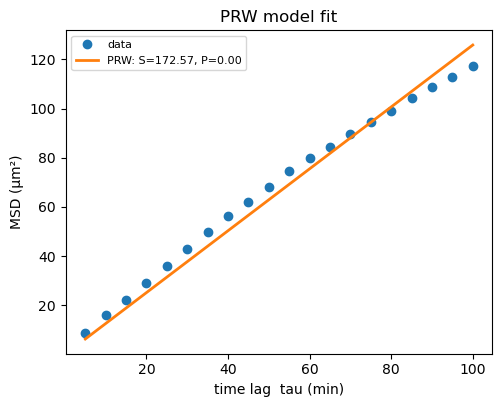

In [26]:
# --- 4) PRW model fit -> speed S and persistence time P ---
#     2D Persistent Random Walk (eq. 4 in the paper):
#       MSD(tau) = 2 * S^2 * P^2 * (exp(-tau/P) + tau/P - 1)
#       S = cell speed (µm/min),  P = persistence time (min)
from scipy.optimize import curve_fit

def prw_msd(tau, S, P):
    return 2 * S**2 * P**2 * (np.exp(-tau / P) + tau / P - 1)

p0 = [np.sqrt(msd[0]) / tau[0], tau[-1] / 2]           # rough speed & persistence
(S, P), _ = curve_fit(prw_msd, tau, msd, p0=p0, maxfev=20000,
                      bounds=([0, 0], [np.inf, np.inf]))
print(f"PRW fit:   speed S = {S:.3f} µm/min,   persistence P = {P:.3f} min")

# --- is the PRW velocity trustworthy here? only if P is resolvable (P > dt) ---
if P < dt:
    v_diff = np.sqrt(msd[0]) / tau[0]                  # apparent speed at shortest lag
    D = np.polyfit(tau[:8], msd[:8], 1)[0] / 4         # 2D diffusivity, MSD = 4 D tau
    print(f"\n!!  P = {P:.2f} min < sampling dt = {dt} min  ->  persistence is BELOW the")
    print( "    imaging resolution, so the PRW 'velocity' S is NOT well-constrained")
    print(f"    (S and P are degenerate). The motion is ~diffusive (alpha={alpha:.2f}).")
    print(f"    Report instead:  diffusivity D = {D:.3f} µm²/min")
    print(f"                     apparent speed at tau={dt} min = {v_diff:.3f} µm/min")
    print( "    -> to actually measure persistence/velocity, image faster than 5 min.")

fig, ax = plt.subplots(figsize=(5.5, 4.2))
ax.plot(tau, msd, "o", label="data")
ax.plot(tau, prw_msd(tau, S, P), "-", lw=2, label=f"PRW: S={S:.2f}, P={P:.2f}")
ax.set_xlabel("time lag  tau (min)"); ax.set_ylabel("MSD (µm²)")
ax.set_title("PRW model fit"); ax.legend(fontsize=8)
plt.show()

### Compare trackers: laptrack vs trackpy (5 min & 10 min)

Note: **CellTracksColab is not a tracker** — it compiles / analyses / visualises tracks that a tracker (TrackMate, laptrack, trackpy, …) already produced. So to compare the *linking* step itself, the apples-to-apples comparison is **laptrack vs trackpy**, both shown below at 5-min and 10-min intervals with the same trajectory visualization used above.

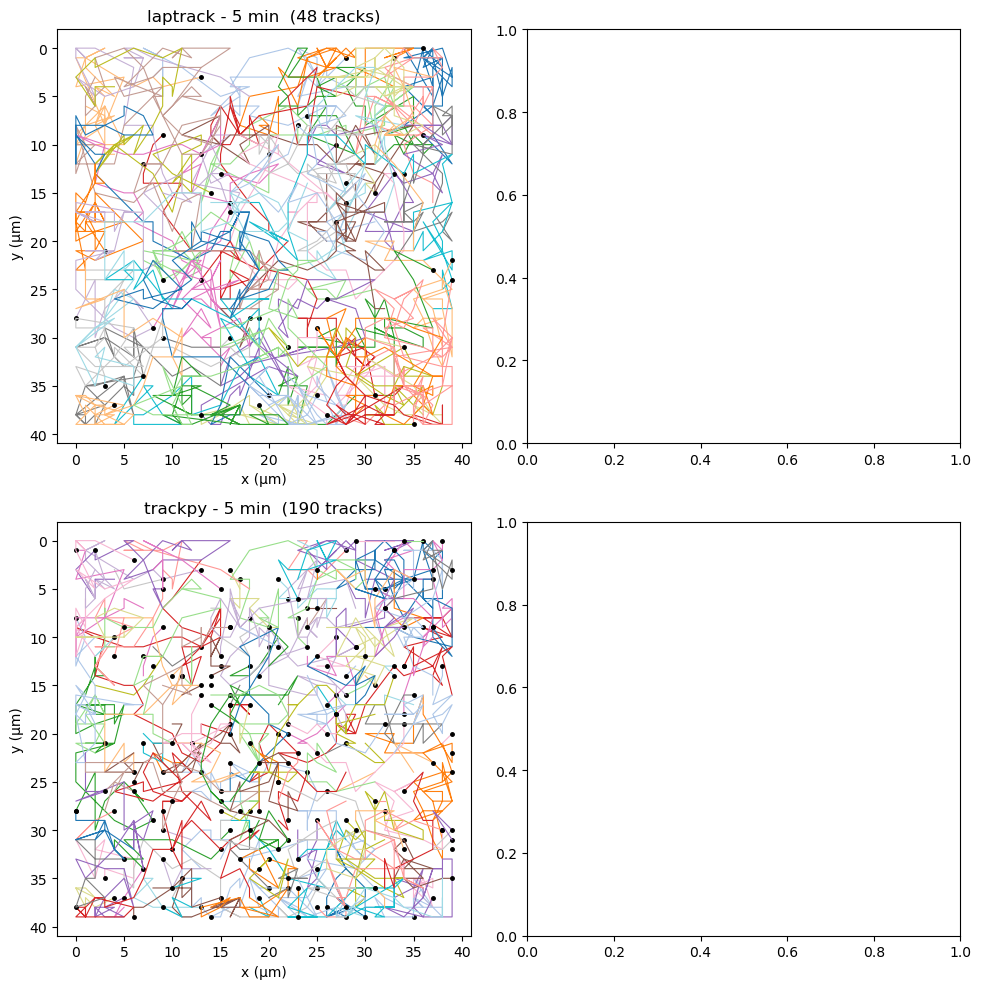

In [30]:
# --- laptrack vs trackpy, at 5 min and 10 min (same viz as the laptrack plot above) ---
# The data is ALWAYS sampled at 5 min. "10 min" simply keeps every 2nd frame (stride=2),
# so one move from frame 0 -> 1 in that reduced movie is a single 10-min step (orig t=0->t=2).
# A cell moves farther in 10 min, so the linking gate is larger for the 10-min case.
import trackpy as tp
import matplotlib.pyplot as plt
import matplotlib.cm as cm
tp.quiet()

A = np.asarray(A_list)

def spots_at(stride):                      # keep every stride-th frame -> detections
    rows = []
    for f, t in enumerate(range(0, A.shape[0], stride)):
        for (y, x) in np.argwhere(A[t] > 0.5):
            rows.append({"frame": f, "y": float(y), "x": float(x)})
    return pd.DataFrame(rows)

def laptrack_df(stride, gate):             # tracker 1
    lt = LapTrack(track_dist_metric="sqeuclidean", track_cost_cutoff=gate**2,
                  gap_closing_max_frame_count=2, gap_closing_cost_cutoff=(2*gate)**2,
                  splitting_cost_cutoff=False, merging_cost_cutoff=False)
    df, _, _ = lt.predict_dataframe(spots_at(stride), coordinate_cols=["x", "y"],
                                    frame_col="frame", only_coordinate_cols=False)
    return df

def trackpy_df(stride, gate):              # tracker 2 (adaptive + memory=0: crowd-safe)
    return tp.link(spots_at(stride), search_range=gate, memory=0,
                   adaptive_stop=0.5, adaptive_step=0.95).rename(
        columns={"particle": "track_id"})

def plot_tracks(ax, df, title):            # same style as the laptrack visualization
    for tid, g in df.groupby("track_id"):
        g = g.sort_values("frame")
        ax.plot(g["x"] * mpp, g["y"] * mpp, "-", lw=0.8, color=cm.tab20(int(tid) % 20))
        ax.plot(g["x"].iloc[0] * mpp, g["y"].iloc[0] * mpp, ".", ms=5, color="k")
    ax.set_aspect("equal"); ax.invert_yaxis()
    ax.set_xlabel("x (µm)"); ax.set_ylabel("y (µm)")
    ax.set_title(f"{title}  ({df.track_id.nunique()} tracks)")

fig, axes = plt.subplots(2, 2, figsize=(10, 10))
# gate: 5 µm for a 5-min move, 10 µm for a (longer) 10-min move
for r, (name, fn) in enumerate([("laptrack", laptrack_df), ("trackpy", trackpy_df)]):
    for c, (label, stride, gate) in enumerate([("5 min", 1, 10.0)]):
        plot_tracks(axes[r, c], fn(stride, gate), f"{name} - {label}")
plt.tight_layout(); plt.show()

In [ ]:
# --- one move: how each method LINKS cells from t=1 (5 min) to t=2 (10 min) ---
# Native 5-min tracking. Circles = cell positions at 5 min (frame 1),
# squares = positions at 10 min (frame 2); each arrow = one tracker's link for this move.
import matplotlib.pyplot as plt

f0, f1 = 1, 2                                    # frame 1 = 5 min, frame 2 = 10 min

def links_between(df, f0, f1):
    """(x0,y0,x1,y1) for each track present in BOTH frames = its link for this move."""
    seg = []
    for tid, g in df.groupby("track_id"):
        g = g.set_index("frame")
        if f0 in g.index and f1 in g.index:
            seg.append((g.loc[f0, "x"], g.loc[f0, "y"], g.loc[f1, "x"], g.loc[f1, "y"]))
    return seg

P0 = np.argwhere(A[f0] > 0.5)                    # detected spots at 5 min
P1 = np.argwhere(A[f1] > 0.5)                    # detected spots at 10 min

fig, axes = plt.subplots(1, 2, figsize=(12, 6))
for ax, (name, df) in zip(axes, [("laptrack", laptrack_df(1, 5.0)),
                                  ("trackpy",  trackpy_df(1, 5.0))]):
    ax.scatter(P0[:, 1], P0[:, 0], s=45, facecolors="none", edgecolors="C0",
               label="t=1 (5 min)")
    ax.scatter(P1[:, 1], P1[:, 0], s=45, marker="s", facecolors="none", edgecolors="C3",
               label="t=2 (10 min)")
    for x0, y0, x1, y1 in links_between(df, f0, f1):
        ax.annotate("", xy=(x1, y1), xytext=(x0, y0),
                    arrowprops=dict(arrowstyle="->", color="k", lw=0.9, alpha=0.75))
    ax.set_aspect("equal"); ax.invert_yaxis()
    ax.set_xlabel("x (µm)"); ax.set_ylabel("y (µm)")
    ax.set_title(f"{name}: link  t=1 (5 min) -> t=2 (10 min)"); ax.legend(fontsize=8)
fig.suptitle("How each method links the single move  t=1 (5 min) -> t=2 (10 min)", fontsize=12)
plt.tight_layout(); plt.show()

In [28]:
# --- difference at 5-min interval: do the two methods give the SAME coordinates per cell? ---
# Both trackers use the SAME detections, so a difference means they LINKED a cell differently.
# Match each cell by its frame-0 position, then compare coordinates frame-by-frame (5 min).
def coord_by_frame(df):
    return {tid: {int(f): (x, y) for f, x, y in zip(g.frame, g.x, g.y)}
            for tid, g in df.groupby("track_id")}

lap = laptrack_df(1, 5.0)                         # 5-min interval, both methods
tpy = trackpy_df(1, 5.0)
L, T = coord_by_frame(lap), coord_by_frame(tpy)
startL = {tid: fr[0] for tid, fr in L.items() if 0 in fr}
startT = {tid: fr[0] for tid, fr in T.items() if 0 in fr}

cells = []
for lid, p0 in startL.items():
    match = [tid for tid, q0 in startT.items() if q0 == p0]   # same starting cell
    if not match:
        continue
    tid = match[0]
    common = sorted(set(L[lid]) & set(T[tid]))
    diffs = np.array([np.hypot(L[lid][f][0] - T[tid][f][0], L[lid][f][1] - T[tid][f][1])
                      for f in common])
    cells.append((p0, lid, tid, common, diffs))

n_ident = sum(c[4].max() == 0 for c in cells)
print(f"cells compared: {len(cells)}   identical tracks: {n_ident}   "
      f"differing: {len(cells) - n_ident}\n")

# ONE cell in detail: laptrack vs trackpy coordinates, frame by frame (the most-different one)
p0, lid, tid, common, diffs = max(cells, key=lambda c: c[4].max())
print(f"Example cell starting at (x,y) = {(round(p0[0]), round(p0[1]))}:")
print(f"{'frame':>6}{'time (min)':>11}{'laptrack (x,y)':>18}{'trackpy (x,y)':>18}{'diff (µm)':>11}")
for f in common:
    lx, ly = L[lid][f]; tx, ty = T[tid][f]
    print(f"{f:>6}{f*dt:>11}{str((round(lx), round(ly))):>18}"
          f"{str((round(tx), round(ty))):>18}{np.hypot(lx - tx, ly - ty):>11.1f}")
print("\n0 µm on every frame = the two methods tracked that cell identically.")

cells compared: 48   identical tracks: 35   differing: 13

Example cell starting at (x,y) = (13, 24):
 frame time (min)    laptrack (x,y)     trackpy (x,y)  diff (µm)
     0          0          (13, 24)          (13, 24)        0.0
     1          5          (11, 24)          (11, 24)        0.0
     2         10          (12, 22)          (12, 22)        0.0
     3         15          (14, 25)          (14, 25)        0.0
     4         20          (12, 26)          (12, 26)        0.0
     5         25          (15, 26)          (13, 26)        2.0
     6         30          (16, 26)          (14, 27)        2.2
     7         35          (16, 25)          (14, 26)        2.2
     8         40          (13, 22)          (14, 24)        2.2
     9         45          (11, 24)          (15, 26)        4.5
    10         50           (9, 24)          (15, 25)        6.1
    11         55          (11, 23)          (18, 24)        7.1
    12         60          (12, 24)          (16, 23)